# 04 · Softmax Regression (multinomial logistic regression)

The extension of logistic regression to $K > 2$ classes. Everything follows the same recipe: linear scores → probabilities → negative log-likelihood → gradient descent.

**Contents**

1. Problem statement and model
2. The softmax function and its properties
3. $K=2$ gives back logistic regression
4. Loss: categorical cross-entropy (= maximum likelihood)
5. Gradient (derivation)
6. Convexity
7. Implementation from scratch and decision regions
8. One-vs-rest vs. softmax; multiclass metrics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0)

## 1. Problem statement and model

Labels $y^{(i)} \in \{1, \dots, K\}$. We want $P(y = k\mid\mathbf{x})$ for every class. Give **each class its own parameter vector** $\boldsymbol{\theta}_k\in\mathbb{R}^{n+1}$ and a linear score (logit)

$$
z_k = \boldsymbol{\theta}_k^\top\mathbf{x}, \qquad k = 1,\dots,K.
$$

Stack them as columns of a matrix $\boldsymbol{\Theta} = [\boldsymbol{\theta}_1, \dots, \boldsymbol{\theta}_K] \in \mathbb{R}^{(n+1)\times K}$, so that $\mathbf{z} = \boldsymbol{\Theta}^\top\mathbf{x}$, and for the whole dataset $\mathbf{Z} = \mathbf{X}\boldsymbol{\Theta}\in\mathbb{R}^{m\times K}$.

Turn the scores into probabilities with the **softmax**:

$$
h_{\boldsymbol{\Theta}}(\mathbf{x})_k = P(y=k\mid\mathbf{x};\boldsymbol{\Theta}) = \mathrm{softmax}(\mathbf{z})_k = \frac{e^{z_k}}{\sum_{l=1}^K e^{z_l}} .
$$

Prediction: $\hat{y} = \arg\max_k h_{\boldsymbol{\Theta}}(\mathbf{x})_k = \arg\max_k \boldsymbol{\theta}_k^\top\mathbf{x}$ (softmax is monotone, so it's the class with the largest score).

## 2. Properties of softmax

1. **A valid distribution**: each output is $>0$ (exponentials) and they sum to 1 (divide by their sum).
2. **Shift invariance**: $\mathrm{softmax}(\mathbf{z} + c\mathbf{1}) = \mathrm{softmax}(\mathbf{z})$.
   *Proof:* $\frac{e^{z_k+c}}{\sum_l e^{z_l+c}} = \frac{e^c e^{z_k}}{e^c\sum_l e^{z_l}}$.
   Consequences: (a) the parameters are **not identifiable**: adding the same vector to every $\boldsymbol{\theta}_k$ changes nothing (regularisation, or fixing $\boldsymbol{\theta}_K=\mathbf{0}$, removes this freedom); (b) **numerical stability**: compute with $\mathbf{z} - \max_l z_l$ so no exponential overflows.
3. **Log-odds between two classes are linear**: $\log\frac{P(y=k\mid\mathbf{x})}{P(y=l\mid\mathbf{x})} = z_k - z_l = (\boldsymbol{\theta}_k - \boldsymbol{\theta}_l)^\top\mathbf{x}$. So the boundary between any two classes is a hyperplane, and the decision regions are convex polygons ("piecewise linear" boundaries).
4. **"Soft" arg-max**: scaling $\mathbf{z}$ by a large factor makes softmax approach the one-hot vector of the arg-max; scaling towards 0 makes it uniform.

## 3. $K = 2$ gives back logistic regression

With two classes:

$$
P(y=1\mid\mathbf{x}) = \frac{e^{z_1}}{e^{z_1} + e^{z_2}} = \frac{1}{1 + e^{-(z_1 - z_2)}} = \sigma\big((\boldsymbol{\theta}_1 - \boldsymbol{\theta}_2)^\top\mathbf{x}\big).
$$

This is logistic regression with $\boldsymbol{\theta} = \boldsymbol{\theta}_1 - \boldsymbol{\theta}_2$. Only the difference matters, which is property 2 again.

## 4. Loss: categorical cross-entropy

Encode the label as a **one-hot** vector $\mathbf{y}^{(i)}\in\{0,1\}^K$ with $y^{(i)}_k = \mathbb{1}[y^{(i)} = k]$, and write $p^{(i)}_k = h_{\boldsymbol{\Theta}}(\mathbf{x}^{(i)})_k$.

The model says $y^{(i)}$ follows a **categorical** distribution: $P(y^{(i)}\mid\mathbf{x}^{(i)};\boldsymbol{\Theta}) = \prod_{k=1}^K \big(p^{(i)}_k\big)^{y^{(i)}_k}$ (only the true class's factor is not 1). The negative mean log-likelihood is

$$
\boxed{J(\boldsymbol{\Theta}) = -\frac{1}{m}\sum_{i=1}^m\sum_{k=1}^K y^{(i)}_k\log p^{(i)}_k = -\frac{1}{m}\sum_{i=1}^m \log p^{(i)}_{y^{(i)}}}
$$

i.e. minus the log of the probability given to the correct class. For $K=2$ it is exactly the binary cross-entropy of notebook 02. Again, **minimising $J$ = maximum likelihood**.

A form that is useful for the derivations: $\;-\log p_{y} = -z_{y} + \log\sum_l e^{z_l}$.

## 5. Gradient

**Step 1: derivative w.r.t. the scores.** For one example with true class $y$, $\ell = -z_y + \log\sum_l e^{z_l}$. Then

$$
\frac{\partial\ell}{\partial z_k} = -\mathbb{1}[y=k] + \frac{e^{z_k}}{\sum_l e^{z_l}} = p_k - y_k .
$$

Written as a vector: $\nabla_{\mathbf{z}}\ell = \mathbf{p} - \mathbf{y}$ (predicted distribution minus one-hot target).

**Step 2: chain rule.** $z_k = \boldsymbol{\theta}_k^\top\mathbf{x}$ depends only on $\boldsymbol{\theta}_k$, with $\nabla_{\boldsymbol{\theta}_k}z_k = \mathbf{x}$. So

$$
\nabla_{\boldsymbol{\theta}_k}J = \frac{1}{m}\sum_{i=1}^m\big(p^{(i)}_k - y^{(i)}_k\big)\,\mathbf{x}^{(i)},
\qquad\text{or for all classes at once}\qquad
\boxed{\nabla_{\boldsymbol{\Theta}}J = \frac{1}{m}\mathbf{X}^\top(\mathbf{P} - \mathbf{Y})}
$$

where $\mathbf{P}, \mathbf{Y}\in\mathbb{R}^{m\times K}$ hold the predicted probabilities and the one-hot labels. Same "(prediction − target) × input" form as linear and logistic regression.

Batch gradient descent: $\boldsymbol{\Theta}\leftarrow\boldsymbol{\Theta} - \alpha\nabla_{\boldsymbol{\Theta}}J$. L2 regularisation adds $\frac{\lambda}{m}\boldsymbol{\Theta}$ to the gradient (except the intercept row).

## 6. Convexity

$J$ is the average of $\ell = -z_y + \mathrm{LSE}(\mathbf{z})$ with $\mathrm{LSE}(\mathbf{z}) = \log\sum_l e^{z_l}$ and $\mathbf{z}$ linear in $\boldsymbol{\Theta}$. A linear term is convex, and a convex function of a linear map is convex, so it is enough to show that **LSE is convex**.

Its gradient is $\mathbf{p} = \mathrm{softmax}(\mathbf{z})$. Differentiating $p_k = e^{z_k}/\sum_l e^{z_l}$ gives $\partial p_k/\partial z_j = p_k(\mathbb{1}[k=j] - p_j)$, so the Hessian is $\mathrm{diag}(\mathbf{p}) - \mathbf{p}\mathbf{p}^\top$. For any $\mathbf{v}$:

$$
\mathbf{v}^\top\big(\mathrm{diag}(\mathbf{p}) - \mathbf{p}\mathbf{p}^\top\big)\mathbf{v} = \sum_k p_kv_k^2 - \Big(\sum_k p_kv_k\Big)^2 = \mathrm{Var}_{k\sim\mathbf{p}}[v_k] \;\ge 0 .
$$

It is a variance, so it is never negative. LSE is convex, hence $J$ is convex. $\blacksquare$ (Not *strictly* convex, because of the shift invariance; L2 regularisation makes it strictly convex.)

## 7. Implementation from scratch

Iris dataset, 3 classes, 2 features (petal length and width) so that we can draw the regions.

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
Xraw, y = iris.data[:, 2:4], iris.target            # petal length, petal width
Xtr_raw, Xte_raw, ytr, yte = train_test_split(Xraw, y, test_size=0.3, stratify=y, random_state=0)
mu, sd = Xtr_raw.mean(0), Xtr_raw.std(0)
add1 = lambda A: np.c_[np.ones(len(A)), (A - mu) / sd]
Xtr, Xte = add1(Xtr_raw), add1(Xte_raw)
K = 3
Ytr = np.eye(K)[ytr]                                 # one-hot (m x K)

def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)             # shift invariance -> no overflow
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

def J(Theta, X, Y, lam=0.0):
    P = softmax(X @ Theta)
    return -np.mean(np.sum(Y * np.log(P + 1e-12), axis=1)) + lam / (2 * len(X)) * np.sum(Theta[1:] ** 2)

def grad_J(Theta, X, Y, lam=0.0):
    G = X.T @ (softmax(X @ Theta) - Y) / len(X)
    G[1:] += lam / len(X) * Theta[1:]
    return G

Theta = np.zeros((Xtr.shape[1], K)); costs = []
for it in range(3000):
    Theta -= 0.5 * grad_J(Theta, Xtr, Ytr, lam=0.1)
    costs.append(J(Theta, Xtr, Ytr, lam=0.1))

acc = np.mean(np.argmax(Xte @ Theta, axis=1) == yte)
print("Theta (rows: intercept, petal length, petal width; columns: classes)\n", Theta.round(2))
print(f"test accuracy = {acc:.3f}")

Theta (rows: intercept, petal length, petal width; columns: classes)
 [[-1.23  3.34 -2.11]
 [-4.07  0.31  3.76]
 [-3.75 -0.85  4.6 ]]
test accuracy = 0.978


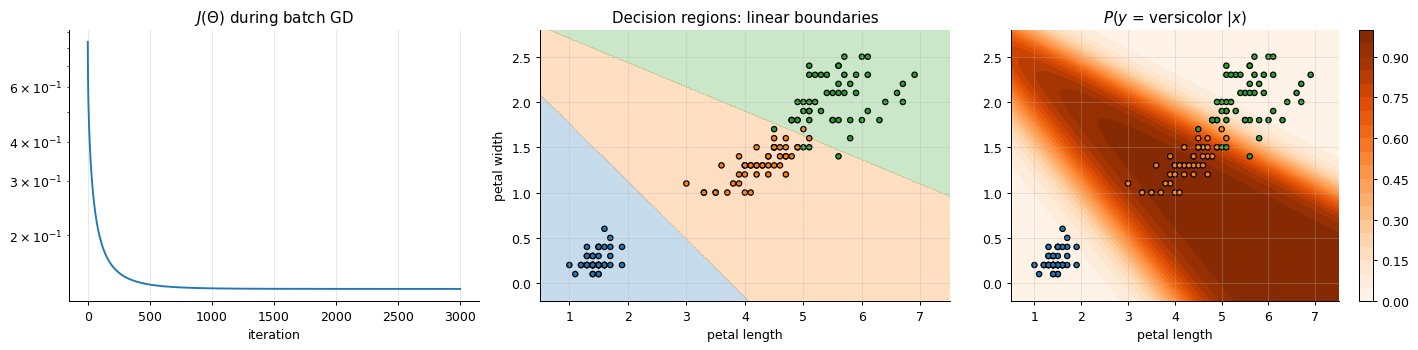

In [3]:
g1, g2 = np.meshgrid(np.linspace(0.5, 7.5, 400), np.linspace(-0.2, 2.8, 400))
G = add1(np.c_[g1.ravel(), g2.ravel()]); Pg = softmax(G @ Theta)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(costs); axes[0].set_yscale("log"); axes[0].set_xlabel("iteration"); axes[0].set_title(r"$J(\Theta)$ during batch GD")
cols = np.array(["C0", "C1", "C2"])
axes[1].contourf(g1, g2, Pg.argmax(1).reshape(g1.shape), levels=[-0.5, 0.5, 1.5, 2.5], colors=cols, alpha=0.25)
axes[1].scatter(Xraw[:, 0], Xraw[:, 1], c=cols[y], edgecolor="k", s=18)
axes[1].set_title("Decision regions: linear boundaries"); axes[1].set_xlabel("petal length"); axes[1].set_ylabel("petal width")
cs = axes[2].contourf(g1, g2, Pg[:, 1].reshape(g1.shape), levels=20, cmap="Oranges"); plt.colorbar(cs, ax=axes[2])
axes[2].scatter(Xraw[:, 0], Xraw[:, 1], c=cols[y], edgecolor="k", s=18)
axes[2].set_title(f"$P(y$ = {iris.target_names[1]} $| x)$"); axes[2].set_xlabel("petal length")
plt.tight_layout(); plt.show()

In [4]:
from sklearn.linear_model import LogisticRegression
# sklearn minimises  C * sum(loss) + 1/2 ||W||^2  ==  mean(loss) + 1/(2 C m) ||W||^2,  so our lambda = 1/C
Theta_long = np.zeros((Xtr.shape[1], K))
for it in range(30000):                     # run our GD to full convergence for a fair comparison
    Theta_long -= 0.5 * grad_J(Theta_long, Xtr, Ytr, lam=0.1)
sk = LogisticRegression(C=1 / 0.1, max_iter=5000, tol=1e-10).fit(Xtr[:, 1:], ytr)   # multinomial for K>2
print("our Theta, centred per row (softmax only identifies differences):\n", (Theta_long - Theta_long.mean(1, keepdims=True)).round(3))
print("sklearn [intercept; coef], centred per row:\n", (np.c_[sk.intercept_, sk.coef_].T - np.c_[sk.intercept_, sk.coef_].T.mean(1, keepdims=True)).round(3))
P_ours = softmax(Xte @ Theta)

our Theta, centred per row (softmax only identifies differences):
 [[-1.231  3.352 -2.121]
 [-4.073  0.297  3.775]
 [-3.766 -0.839  4.605]]
sklearn [intercept; coef], centred per row:
 [[-1.231  3.352 -2.121]
 [-4.073  0.297  3.775]
 [-3.766 -0.839  4.605]]


## 8. One-vs-rest vs. softmax; multiclass metrics

**Two ways to do multiclass with a binary classifier:**

| | One-vs-rest (OvR) | Softmax (multinomial) |
|---|---|---|
| Training | $K$ independent binary logistic regressions ("class $k$" vs "the rest") | one joint model, one loss |
| Probabilities | the $K$ outputs don't sum to 1 (need re-normalising) | a proper distribution by construction |
| When | any binary classifier (e.g. SVMs, notebook 05); classes not mutually exclusive (multi-label) | mutually exclusive classes |

**Metrics.** The confusion matrix becomes $K\times K$. Precision, recall and $F_1$ are computed **per class** (that class vs. the rest) and averaged:
- **macro** average: plain mean over classes, every class counts the same (good for imbalanced classes, where you care about rare classes);
- **weighted** average: weighted by class frequency;
- **micro** average: pool all TP/FP/FN first; for single-label problems it equals accuracy.

Log-loss (= $J$ on the test set) evaluates the probabilities.

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.938     1.000     0.968        15
   virginica      1.000     0.933     0.966        15

    accuracy                          0.978        45
   macro avg      0.979     0.978     0.978        45
weighted avg      0.979     0.978     0.978        45

test log-loss = 0.083


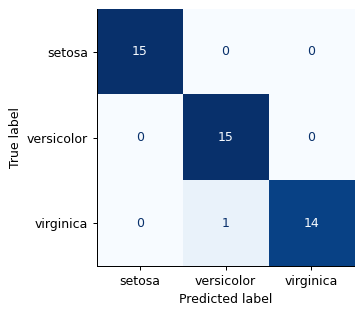

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, log_loss
yhat = P_ours.argmax(1)
print(classification_report(yte, yhat, target_names=iris.target_names, digits=3))
print(f"test log-loss = {log_loss(yte, P_ours):.3f}")
fig, ax = plt.subplots(figsize=(4, 3.6))
ConfusionMatrixDisplay.from_predictions(yte, yhat, display_labels=iris.target_names, ax=ax, colorbar=False, cmap="Blues")
ax.grid(False); plt.tight_layout(); plt.show()

## Summary

- One parameter vector per class; scores $z_k = \boldsymbol{\theta}_k^\top\mathbf{x}$; probabilities $\mathrm{softmax}(\mathbf{z})$.
- Loss: categorical cross-entropy = negative log-likelihood of a categorical distribution.
- Gradient: $\frac1m\mathbf{X}^\top(\mathbf{P}-\mathbf{Y})$; convex (Hessian of log-sum-exp is a covariance).
- $K=2$ is logistic regression; boundaries between classes are hyperplanes.
- Implementation detail: subtract $\max_k z_k$ before exponentiating.